In [1]:
import pandas as pd
import glob
import os
import warnings

warnings.filterwarnings("ignore")

In [2]:


# Define folder path
folder_path = "/Users/dougs/Annapurna Dropbox/Doug Sack/Interactive/IndieBI/sales_curve_data/units/"

# Get all .xlsx files in the folder
files = glob.glob(f"{folder_path}/*.xlsx")

# Read all files into DataFrames and add filename column
dfs = [pd.read_excel(file, skiprows=2).assign(Source=os.path.basename(file)) for file in files]




In [3]:
df = pd.concat(dfs, ignore_index=True)


In [4]:
folder_path = "wishlists/Games Sales Curve Categorizations - overall.csv"
categories  = pd.read_csv(folder_path)
import ast
categories['curve_category'] = categories['curve_category'].fillna("overall")
categories = categories.dropna(subset='curve_category')
categories['curve_category'] = categories['curve_category'].apply(
    lambda x: list(set(x.split(', ') + ['overall']))
)

In [5]:
categories

,product,curve_category
0,Twelve Minutes,"[front-loaded, no-presale, overall]"
1,Ashen,"[presale, overall]"
2,Maquette,"[linear, overall, low perf, front-loaded, no-p..."
3,Open Roads,"[low perf, front-loaded, no-presale, overall]"
4,Thirsty Suitors,"[low perf, front-loaded, no-presale, overall]"
5,Lorelei and the Laser Eyes,"[no-presale, front-loaded, secondary-surge, ov..."
6,Cocoon,"[front-loaded, presale, overall]"
7,Donut County,"[presale, linear, overall]"
8,Due Process,"[front-loaded, presale, overall]"
9,Storyteller,"[no-presale, front-loaded, secondary-surge, ov..."


In [6]:
categories.explode('curve_category').curve_category.unique()

array(['front-loaded', 'no-presale', 'overall', 'presale', 'linear',
       'low perf', 'secondary-surge', 'high perf'], dtype=object)

In [7]:
categories = categories.explode('curve_category')

In [8]:
category_selector = 'overall'

In [9]:
catgory_filtered_df = categories.query("curve_category ==@category_selector")

In [10]:
category_filter = list(catgory_filtered_df['product'].unique())

In [11]:
category_filter

['Twelve Minutes',
 'Ashen',
 'Maquette',
 'Open Roads',
 'Thirsty Suitors',
 'Lorelei and the Laser Eyes',
 'Cocoon',
 'Donut County',
 'Due Process',
 'Storyteller',
 'Mundaun',
 'Flock',
 'Telling Lies',
 'The Unfinished Swan',
 'Gorogoa',
 'Hindsight',
 'Hohokum',
 'I Am Dead',
 'A Memoir Blue',
 'Journey',
 'Kentucky Route Zero: TV Edition',
 'Florence',
 'Flower',
 'The Artful Escape',
 'If Found...',
 'BattleSage',
 'Big Hops',
 'Blade Runner 2033: Labyrinth',
 'Neon White',
 'Bounty Star',
 'Outer Wilds',
 'Faraway',
 'Forever Ago',
 'Sayonara Wild Hearts',
 'Last Stop',
 'Solar Ash',
 'Lushfoil Photography Sim',
 'Stray',
 'Mixtape',
 'Morsels',
 'Outer Wilds - Archaeologist Edition BUNDLE',
 'The Pathless',
 'Project D',
 'Skin Deep',
 'The Lost Wild',
 'to a T',
 'Wanderstop',
 'Wattam',
 'We Kill Monsters',
 'What Remains of Edith Finch',
 'Wheel World']

In [12]:
df.head()

,Date,product,Cumulative Selected Measure,Source
0,2018-03-13,Florence,356,google.xlsx
1,2018-03-14,Florence,2720,google.xlsx
2,2018-03-15,Florence,4017,google.xlsx
3,2018-03-16,Florence,4655,google.xlsx
4,2018-03-17,Florence,5074,google.xlsx


## File Name

In [14]:
df.Source.unique()

array(['google.xlsx', 'nintendo.xlsx', 'playstation.xlsx', 'epic.xlsx',
       'gog.xlsx', 'steam.xlsx', 'xbox.xlsx', 'apple.xlsx', 'humble.xlsx'],
      dtype=object)

In [15]:
file_name = 'humble'

In [16]:
folder_path = "wishlists/Annapurna Interactive Historical Revenues - releases_dates.csv"
dates  = pd.read_csv(folder_path)
dates = dates.dropna(subset='pc_release_date')
dates['pc_release_date'] = pd.to_datetime(dates['pc_release_date'])
release_date_dict = dates.groupby('product')['pc_release_date'].min().to_dict()

In [17]:
df_combined = df.query(f"Source =='{file_name}.xlsx'")
#df_combined['release_date'] = df_combined['product'].map(release_dict)

In [18]:
release_date_dict

{'A Memoir Blue': Timestamp('2022-03-24 00:00:00'),
 'Ashen': Timestamp('2019-12-09 00:00:00'),
 'BattleSage': Timestamp('2025-06-30 00:00:00'),
 'Bounty Star': Timestamp('2025-10-07 00:00:00'),
 'Cocoon': Timestamp('2023-09-29 00:00:00'),
 'Donut County': Timestamp('2018-08-28 00:00:00'),
 'Due Process': Timestamp('2020-11-03 00:00:00'),
 'Faraway': Timestamp('2025-12-31 00:00:00'),
 'Flock': Timestamp('2024-07-16 00:00:00'),
 'Florence': Timestamp('2020-02-13 00:00:00'),
 'Flower': Timestamp('2019-02-14 00:00:00'),
 'Gorogoa': Timestamp('2017-12-14 00:00:00'),
 'Hindsight': Timestamp('2022-08-04 00:00:00'),
 'Hohokum': Timestamp('2022-07-28 00:00:00'),
 'I Am Dead': Timestamp('2020-10-08 00:00:00'),
 'If Found...': Timestamp('2020-05-19 00:00:00'),
 'Journey': Timestamp('2020-06-11 00:00:00'),
 'Kentucky Route Zero: TV Edition': Timestamp('2020-01-28 00:00:00'),
 'LEGO Voyagers': Timestamp('2025-09-30 00:00:00'),
 'Last Stop': Timestamp('2021-07-22 00:00:00'),
 'Lorelei and the Laser

In [19]:
dates.sort_values(by='product')

,product,pc_release_date
21,A Memoir Blue,2022-03-24
38,Ashen,2019-12-09
4,BattleSage,2025-06-30
46,Bounty Star,2025-10-07
14,Cocoon,2023-09-29
41,Donut County,2018-08-28
29,Due Process,2020-11-03
0,Faraway,2025-12-31
10,Flock,2024-07-16
35,Florence,2020-02-13


In [20]:
df_combined

,Date,product,Cumulative Selected Measure,Source
224645,2022-02-21,Ashen,9,humble.xlsx
224646,2022-02-21,Ashen - Nightstorm Isle DLC,8,humble.xlsx
224647,2022-02-21,Donut County,15,humble.xlsx
224648,2022-02-21,Florence,14,humble.xlsx
224649,2022-02-21,Flower,13,humble.xlsx
...,...,...,...,...
257800,2025-06-16,The Unfinished Swan,600,humble.xlsx
257801,2025-06-16,Thirsty Suitors,110,humble.xlsx
257802,2025-06-16,Twelve Minutes,719,humble.xlsx
257803,2025-06-16,Wattam,380,humble.xlsx


In [21]:
df_combined['release_date'] = pd.to_datetime(df_combined['Date'])

In [22]:
df_combined['release_date'] = df_combined.groupby('product')['release_date'].transform('min')

In [23]:
df_combined["DAR"] = (df_combined["Date"] - df_combined["release_date"]).dt.days
#df_combined["DAR"] = df_combined["DAR"].clip(lower=0)

df_combined["Weeks_from_Release"] = (df_combined["DAR"] // 7) + 1  # Week 1 starts at 0-7 days
#df_combined["Months_from_Release"] = (df_combined["DAR"] // 30) + 1  # Week 1 starts at 0-7 days


time_frame = "weekly"
df_combined = df_combined.query("0 <= Weeks_from_Release <=156")

df_combined = df_combined.query("'1/1/2020' <= release_date <= '1/1/2024'")

df_combined = df_combined.groupby(["product", "Weeks_from_Release"], as_index=False)["Cumulative Selected Measure"].max()

In [24]:
title_exclusion = ['Ashen', 'Ashen - Nightstorm Isle DLC',
       'Ashen Definitive Edition',]

In [25]:
title_exclusion = [
'Stray','Outer Wilds','Ashen', 'Ashen - Nightstorm Isle DLC',
       'Ashen Definitive Edition', 'Outer Wilds - Archaeologist Edition BUNDLE',
       'Outer Wilds - Echoes of the Eye DLC','I Am Dead','Gorogoa','Last Stop','Telling Lies']

In [26]:
title_exclusion = [
'Stray','Outer Wilds','Outer Wilds - Echoes of the Eye DLC'
]

In [27]:
title_exclusion = []

In [28]:
df_combined['product'].unique()

array(['A Memoir Blue', 'Ashen', 'Ashen - Nightstorm Isle DLC', 'Cocoon',
       'Donut County', 'Due Process', 'Florence', 'Flower', 'Gorogoa',
       'Hindsight', 'Hohokum', 'I Am Dead', 'If Found...', 'Journey',
       'Last Stop', 'Maquette', 'Neon White', 'Outer Wilds',
       'Outer Wilds - Echoes of the Eye DLC', 'Sayonara Wild Hearts',
       'Solar Ash', 'Storyteller', 'Telling Lies', 'The Artful Escape',
       'The Pathless', 'The Unfinished Swan', 'Thirsty Suitors',
       'Twelve Minutes', 'Wattam', 'What Remains of Edith Finch'],
      dtype=object)

In [29]:
df_combined

,product,Weeks_from_Release,Cumulative Selected Measure
0,A Memoir Blue,1,12
1,A Memoir Blue,2,13
2,A Memoir Blue,3,15
3,A Memoir Blue,4,15
4,A Memoir Blue,5,15
...,...,...,...
4296,What Remains of Edith Finch,152,2100
4297,What Remains of Edith Finch,153,2155
4298,What Remains of Edith Finch,154,2270
4299,What Remains of Edith Finch,155,2449


In [30]:
df_combined = df_combined.query("product !=@title_exclusion")

In [31]:
df_combined = df_combined.query("product==@category_filter")

In [32]:
df_combined['product'].unique()

array(['A Memoir Blue', 'Ashen', 'Cocoon', 'Donut County', 'Due Process',
       'Florence', 'Flower', 'Gorogoa', 'Hindsight', 'Hohokum',
       'I Am Dead', 'If Found...', 'Journey', 'Last Stop', 'Maquette',
       'Neon White', 'Outer Wilds', 'Sayonara Wild Hearts', 'Solar Ash',
       'Storyteller', 'Telling Lies', 'The Artful Escape', 'The Pathless',
       'The Unfinished Swan', 'Thirsty Suitors', 'Twelve Minutes',
       'Wattam', 'What Remains of Edith Finch'], dtype=object)

## Xbox Smoothing

In [34]:
smoothing_cat = "raw"

In [35]:
# Sort for safety
df_combined = df_combined.sort_values(['product', 'Weeks_from_Release'])

# Smooth cumulative values using rolling average (e.g., 3-week window)
df_combined['Cumulative Selected Measure'] = (
    df_combined
    .groupby('product')['Cumulative Selected Measure']
    .transform(lambda x: x.rolling(window=12, min_periods=1, center=True).mean())
)


smoothing_cat = "smoothed"

In [36]:
df_combined["percent_of_max"] = df_combined["Cumulative Selected Measure"] / df_combined.groupby("product")["Cumulative Selected Measure"].transform("max")
#df_combined

In [37]:
#pd.set_option("display.max_rows", None)


df_combined["CUME_total"] = df_combined.groupby(["product"])["Cumulative Selected Measure"].transform("max")
df_combined["prop_of_total"] = df_combined["Cumulative Selected Measure"] / df_combined["CUME_total"]
df_combined["daily_delta"] = df_combined.groupby(["product"])["Cumulative Selected Measure"].pct_change().fillna(0)

df_combined.query("product=='Ashen' & Weeks_from_Release <=52")
#df_combined.query("product=='Ashen' & Months_from_Release <=12")


,product,Weeks_from_Release,Cumulative Selected Measure,percent_of_max,CUME_total,prop_of_total,daily_delta
156,Ashen,1,148.000000,0.279170,530.142857,0.279170,0.000000
157,Ashen,2,148.428571,0.279978,530.142857,0.279978,0.002896
158,Ashen,3,148.875000,0.280821,530.142857,0.280821,0.003008
159,Ashen,4,149.222222,0.281475,530.142857,0.281475,0.002332
160,Ashen,5,149.500000,0.281999,530.142857,0.281999,0.001862
161,Ashen,6,149.727273,0.282428,530.142857,0.282428,0.001520
162,Ashen,7,149.916667,0.282785,530.142857,0.282785,0.001265
163,Ashen,8,151.333333,0.285458,530.142857,0.285458,0.009450
164,Ashen,9,151.500000,0.285772,530.142857,0.285772,0.001101
165,Ashen,10,151.666667,0.286086,530.142857,0.286086,0.001100


In [38]:
audit = df_combined.query("Weeks_from_Release <=52").pivot(index='product', columns='Weeks_from_Release',values='daily_delta').reset_index()
audit.sort_values(by=2,ascending=False)

Weeks_from_Release,product,1,2,3,4,5,6,7,8,9,...,43,44,45,46,47,48,49,50,51,52
14,Maquette,0.0,0.282113,0.169944,0.112979,0.081208,0.061453,0.048246,0.085774,0.077071,...,0.007455,0.009514,0.009424,0.009336,0.008222,0.007136,0.007085,0.007035,0.006986,0.009911
21,The Artful Escape,0.0,0.178571,0.140152,0.099053,0.074922,0.057027,0.044959,0.083168,0.069470,...,0.016051,0.020537,0.023994,0.023432,0.018464,0.016679,0.011412,0.009873,0.009078,0.008997
24,Thirsty Suitors,0.0,0.125541,0.144231,0.118954,0.089252,0.084591,0.076861,0.126722,0.100244,...,0.011121,0.010082,0.005445,0.005415,0.005386,0.001786,0.000891,0.000890,0.000890,0.000889
18,Solar Ash,0.0,0.116170,0.107595,0.075556,0.063636,0.063785,0.062749,0.125430,0.083969,...,0.018674,0.013094,0.011078,0.010592,0.008674,0.005374,0.000713,0.000000,0.000000,0.000000
9,Hohokum,0.0,0.100529,0.076923,0.062500,0.070588,0.058941,0.050708,0.098765,0.067416,...,0.023256,0.010695,0.010582,0.010471,0.006477,0.003861,0.000000,0.000000,0.000000,0.000000
27,What Remains of Edith Finch,0.0,0.100112,0.092945,0.066143,0.049631,0.038687,0.031602,0.060623,0.052008,...,0.022463,0.026285,0.032492,0.033321,0.029559,0.025753,0.017133,0.014843,0.014297,0.016688
19,Storyteller,0.0,0.095164,0.091880,0.067189,0.051834,0.056168,0.053121,0.129572,0.081406,...,0.012798,0.010886,0.010385,0.010088,0.009798,0.008397,0.005181,0.002025,0.001837,0.001834
15,Neon White,0.0,0.084376,0.063048,0.052904,0.043854,0.037027,0.030927,0.103095,0.082319,...,0.011529,0.010944,0.009142,0.008671,0.008045,0.008363,0.009920,0.009769,0.009090,0.015751
8,Hindsight,0.0,0.061688,0.043578,0.039316,0.030263,0.029258,0.023689,0.100000,0.078512,...,0.004878,0.004854,0.004831,0.004808,0.026316,0.030303,0.029412,0.028571,0.027778,0.029106
2,Cocoon,0.0,0.049470,0.133838,0.209602,0.161457,0.117196,0.089310,0.176726,0.171218,...,0.020980,0.022582,0.022296,0.018337,0.014324,0.012104,0.010631,0.009598,0.006772,0.006662


In [39]:
# Flatten the DataFrame and filter values > 5
filtered = audit.set_index('product').stack()
high_vals = filtered[filtered > 3]

# Sort descending to find the highest ones
top_high_vals = high_vals.sort_values(ascending=False)

top_high_vals.sort_index(level='product')

Series([], dtype: float64)

In [40]:
platform_df = df_combined.groupby("Weeks_from_Release")[['daily_delta','prop_of_total']].mean()
platform_df['platform'] = file_name

In [41]:
platform_df.query(" Weeks_from_Release <=52")

,daily_delta,prop_of_total,platform
Weeks_from_Release,,,
1,0.000000,0.127508,humble
2,0.047337,0.132972,humble
3,0.043257,0.138490,humble
4,0.037762,0.143564,humble
5,0.030369,0.147973,humble
6,0.026077,0.152129,humble
7,0.022458,0.155960,humble
8,0.050300,0.164468,humble
9,0.037259,0.171385,humble


In [42]:
platform_df.to_csv(f"units/{file_name}_{category_selector}_average_{smoothing_cat}_{time_frame}.csv")

In [43]:
df_combined

,product,Weeks_from_Release,Cumulative Selected Measure,percent_of_max,CUME_total,prop_of_total,daily_delta
0,A Memoir Blue,1,14.500000,0.104855,138.285714,0.104855,0.000000
1,A Memoir Blue,2,15.000000,0.108471,138.285714,0.108471,0.034483
2,A Memoir Blue,3,15.375000,0.111183,138.285714,0.111183,0.025000
3,A Memoir Blue,4,15.777778,0.114096,138.285714,0.114096,0.026197
4,A Memoir Blue,5,16.100000,0.116426,138.285714,0.116426,0.020423
...,...,...,...,...,...,...,...
4296,What Remains of Edith Finch,152,2171.909091,0.969973,2239.142857,0.969973,0.004893
4297,What Remains of Edith Finch,153,2184.600000,0.975641,2239.142857,0.975641,0.005843
4298,What Remains of Edith Finch,154,2200.111111,0.982568,2239.142857,0.982568,0.007100
4299,What Remains of Edith Finch,155,2218.625000,0.990837,2239.142857,0.990837,0.008415


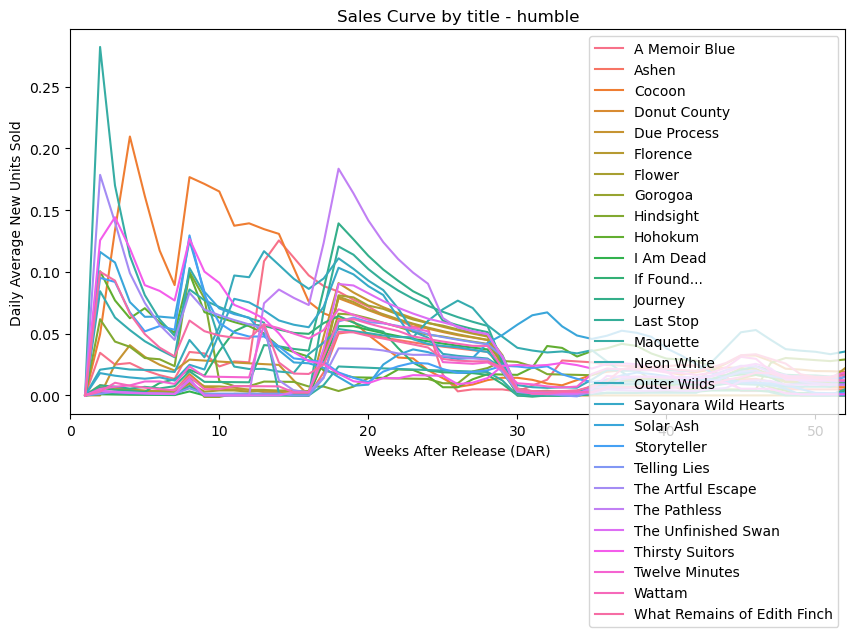

In [44]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))  # Adjust figure size for better visibility

sns.lineplot(data=df_combined, x='Weeks_from_Release', y='daily_delta', hue='product')
# Improve aesthetics
plt.xlabel("Weeks After Release (DAR)")
plt.ylabel("Daily Average New Units Sold")
plt.title(f"Sales Curve by title - {file_name}")
plt.legend(loc="best")
#plt.tight_layout()# Set legend title
plt.xlim(0,52)
plt.show()

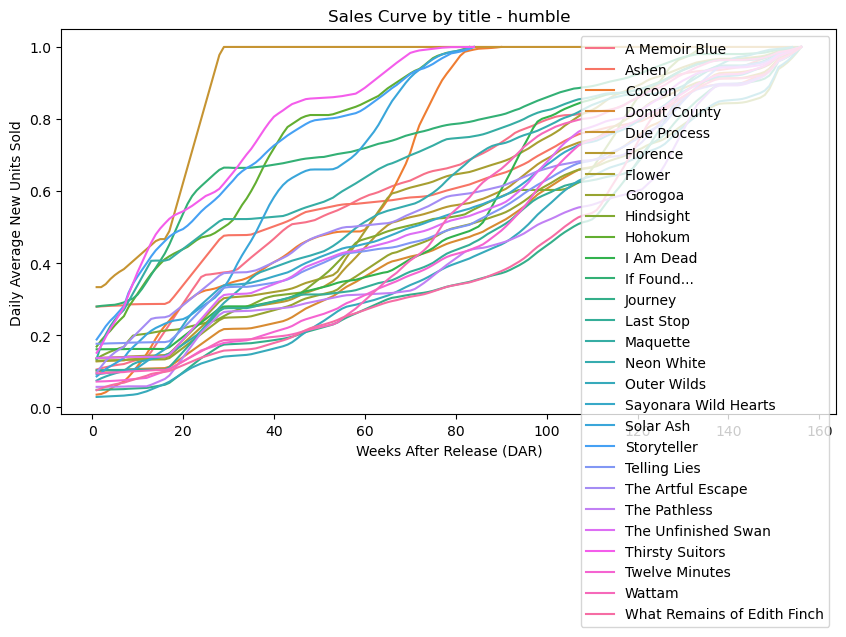

In [45]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))  # Adjust figure size for better visibility

sns.lineplot(data=df_combined, x='Weeks_from_Release', y='prop_of_total', hue='product')
# Improve aesthetics
plt.xlabel("Weeks After Release (DAR)")
plt.ylabel("Daily Average New Units Sold")
plt.title(f"Sales Curve by title - {file_name}")
plt.legend(loc="best")
#plt.tight_layout()# Set legend title
plt.savefig(f"{file_name}.png")
plt.show()

In [46]:
stop

NameError: name 'stop' is not defined

In [47]:
### Fit the Curve to a model and use this to predict



# Define folder path
folder_path = "/Users/dougs/Documents/GitHub/IndieBI-Sales-EDA/units/"

# Get all .xlsx files in the folder
files = glob.glob(f"{folder_path}/*{category_selector}*{smoothing_cat}*{time_frame}*.csv")

# Read all files into DataFrames and add filename column
dfs = [pd.read_csv(file).assign(Source=os.path.basename(file)) for file in files]




In [49]:
files

['/Users/dougs/Documents/GitHub/IndieBI-Sales-EDA/units/google_overall_average_smoothed_weekly.csv',
 '/Users/dougs/Documents/GitHub/IndieBI-Sales-EDA/units/gog_overall_average_smoothed_weekly.csv',
 '/Users/dougs/Documents/GitHub/IndieBI-Sales-EDA/units/nintendo_overall_average_smoothed_weekly.csv',
 '/Users/dougs/Documents/GitHub/IndieBI-Sales-EDA/units/epic_overall_average_smoothed_weekly.csv',
 '/Users/dougs/Documents/GitHub/IndieBI-Sales-EDA/units/steam_overall_average_smoothed_weekly.csv',
 '/Users/dougs/Documents/GitHub/IndieBI-Sales-EDA/units/playstation_overall_average_smoothed_weekly.csv',
 '/Users/dougs/Documents/GitHub/IndieBI-Sales-EDA/units/xbox_overall_average_smoothed_weekly.csv',
 '/Users/dougs/Documents/GitHub/IndieBI-Sales-EDA/units/humble_overall_average_smoothed_weekly.csv']

In [51]:
smoothing_cat

'smoothed'

In [52]:
av_df = pd.concat(dfs, ignore_index=True)


In [53]:
platforms = av_df.pivot_table(columns='platform', index='Weeks_from_Release', values='daily_delta').reset_index()

In [54]:
platforms.to_clipboard()

In [55]:
platforms.columns[1:]

Index(['epic', 'gog', 'google', 'humble', 'nintendo', 'playstation', 'steam',
       'xbox'],
      dtype='object', name='platform')

In [56]:
rimage_folder_path = "Documents/GitHub/IndieBI-Sales-EDA/sales_curve_image_comparison"

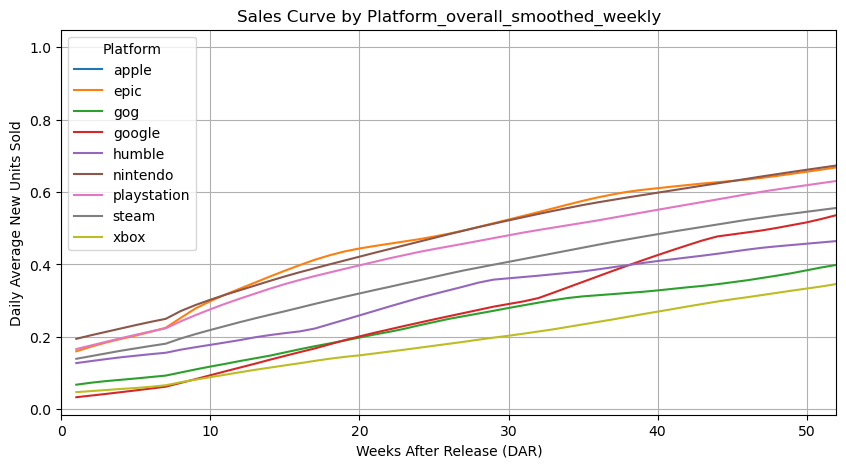

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))  # Adjust figure size for better visibility

# Loop through unique platforms and plot each separately
for platform in ['apple', 'epic', 'gog', 'google', 'humble', 'nintendo', 'playstation',
       'steam', 'xbox']:
    pdf = av_df.query("platform == @platform")
    sns.lineplot(data=pdf, x='Weeks_from_Release', y='prop_of_total', label=platform)

# Improve aesthetics
plt.xlabel("Weeks After Release (DAR)")
plt.ylabel("Daily Average New Units Sold")
plt.title(f"Sales Curve by Platform_{category_selector}_{smoothing_cat}_{time_frame}")
plt.legend(title="Platform", loc="best")  # Set legend title
plt.xlim(0, 52)
plt.grid(True)  # Add grid for readability

plt.savefig(f"sales_curve_image_comparison/pct_total_{category_selector}_{smoothing_cat}_{time_frame}.png")
plt.show()

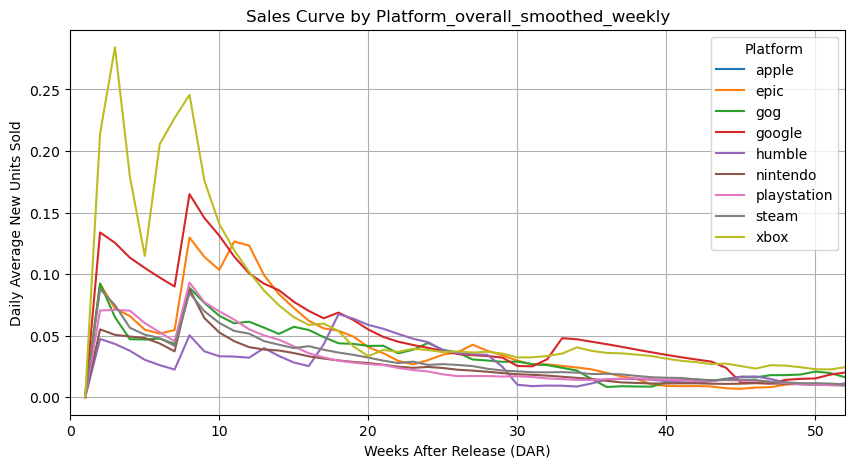

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))  # Adjust figure size for better visibility

# Loop through unique platforms and plot each separately
for platform in ['apple', 'epic', 'gog', 'google', 'humble', 'nintendo', 'playstation',
       'steam', 'xbox']:
    pdf = av_df.query("platform == @platform")
    sns.lineplot(data=pdf, x='Weeks_from_Release', y='daily_delta', label=platform)

# Improve aesthetics
plt.xlabel("Weeks After Release (DAR)")
plt.ylabel("Daily Average New Units Sold")
plt.title(f"Sales Curve by Platform_{category_selector}_{smoothing_cat}_{time_frame}")
plt.legend(title="Platform", loc="best")  # Set legend title
plt.xlim(0,52)
plt.grid(True)  # Add grid for readability
plt.savefig(f"sales_curve_image_comparison/daily_delta_{category_selector}_{smoothing_cat}_{time_frame}.png")

plt.show()